In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/creditcard.csv'

In [3]:
import os
os.listdir('/content/drive/MyDrive/')


['Colab Notebooks',
 'Classroom',
 'Passbook.pdf',
 'MTECHCSE_SharedPrep',
 'MTechCSE_SharedResource',
 'tutorial3.gdoc',
 'PSCS.zip',
 'FTCS.zip',
 'DOC-20251009-WA0003..pdf',
 'Document from Vishakh (2)',
 'DeepfakeDataset',
 'WhatsApp Image 2025-11-19 at 07.39 (1).55_7c5c2272.jpg',
 'WhatsApp Image 2025-11-19 at 07.39.55_7c5c2272.jpg',
 'lab3.py',
 'faithful (2).gsheet',
 'faithful (1).gsheet',
 'faithful.gsheet',
 'dataset.gsheet',
 'Copy of Updated_Seam_Carving_Presentation_2.pptx',
 'Document from Vishakh (1)',
 'Assign',
 'Document from Vishakh',
 'Seam_Carving_Code']

In [4]:
import subprocess
result = subprocess.run(['find', '/content/drive/MyDrive', '-name', 'creditcard.csv'],
                      capture_output=True, text=True)
print(result.stdout)


In [6]:
from google.colab import files
uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


In [7]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [8]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [9]:
print(df.isnull().sum().sum())
print(df.describe()[['Amount', 'Time']])

0
              Amount           Time
count  284807.000000  284807.000000
mean       88.349619   94813.859575
std       250.120109   47488.145955
min         0.000000       0.000000
25%         5.600000   54201.500000
50%        22.000000   84692.000000
75%        77.165000  139320.500000
max     25691.160000  172792.000000


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Amount scale karo, Time drop karo
df['Amount_scaled'] = StandardScaler().fit_transform(df['Amount'].values.reshape(-1,1))
df = df.drop(['Time', 'Amount'], axis=1)

# Features aur target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts())

Train size: (227845, 29)
Test size: (56962, 29)

Train class distribution:
Class
0    227451
1       394
Name: count, dtype: int64


In [11]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_sm.value_counts())

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.97


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9737


In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9753


In [15]:
xgb2 = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=577
)
xgb2.fit(X_train_sm, y_train_sm)

y_pred_xgb2 = xgb2.predict(X_test)
y_prob_xgb2 = xgb2.predict_proba(X_test)[:,1]

print("XGBoost Tuned Results:")
print(classification_report(y_test, y_pred_xgb2))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb2), 4))

XGBoost Tuned Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.87      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9739


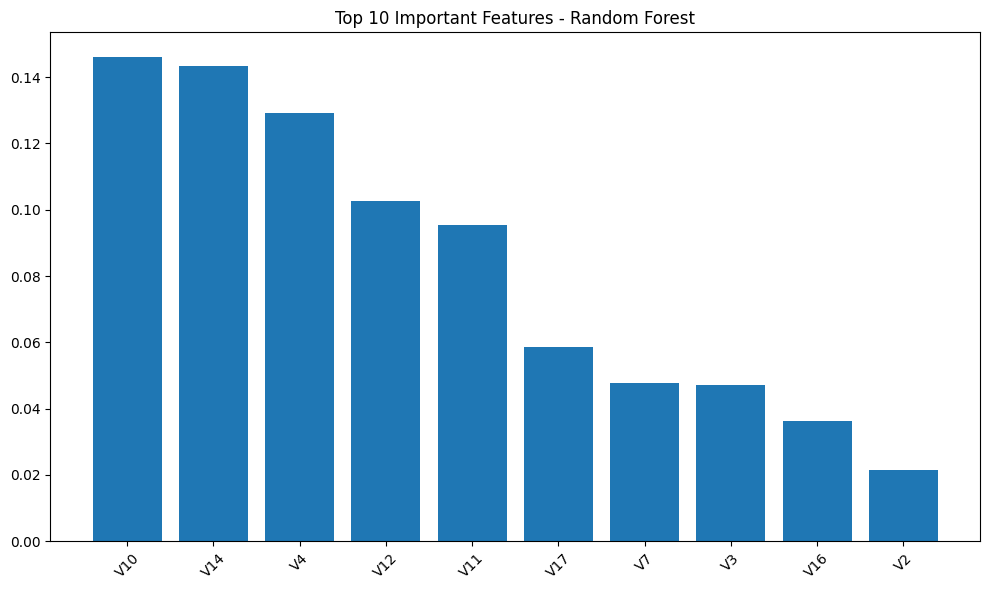

In [16]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
features = X.columns[indices]

plt.figure(figsize=(10,6))
plt.bar(features, importances[indices])
plt.title("Top 10 Important Features - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

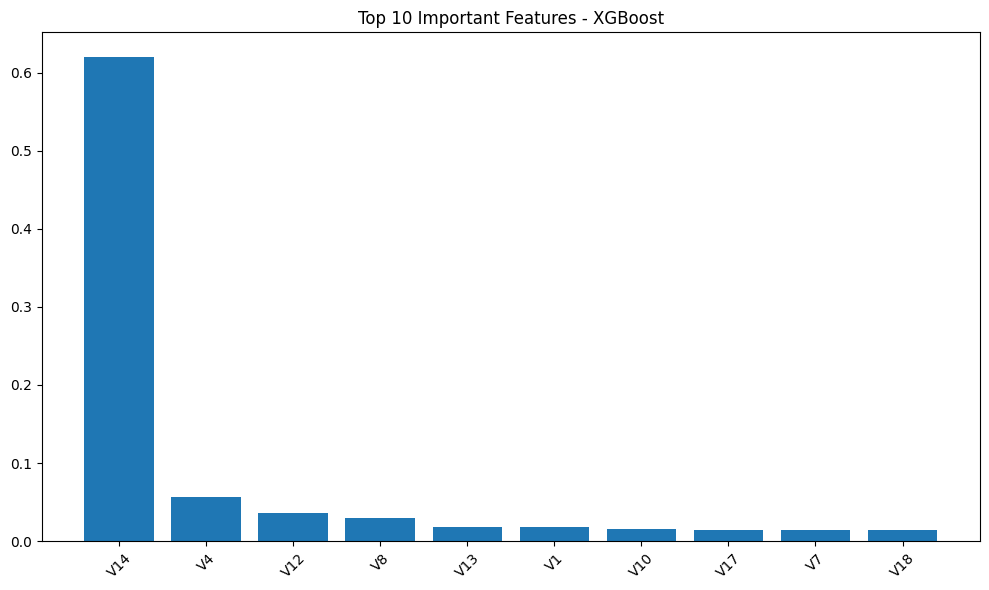

In [17]:
import matplotlib.pyplot as plt
import numpy as np

importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1][:10]
features = X.columns[indices]

plt.figure(figsize=(10,6))
plt.bar(features, importances[indices])
plt.title("Top 10 Important Features - XGBoost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()